In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

df.head()

,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [7]:
# Create classification target
df["High_Performance"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

TARGET = "High_Performance"

df[TARGET].value_counts()

High_Performance
0    5000
1    5000
Name: count, dtype: int64

In [8]:
# Drop useless columns
df = df.drop(columns=[
    "Campaign_ID","Product_ID","Customer_ID",
    "Bundle_ID","Common_Keywords"
], errors='ignore')

# Remove missing
df = df.dropna()

# Encode categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

df.head()

,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,High_Performance
0,41770.45,4946,73,15520.09,1.94,1,4,501,43,34,433.80,4,0
1,29900.93,570,510,30866.17,0.76,1,4,427,28,97,289.29,2,0
2,22367.45,3546,265,32585.62,1.41,0,9,5305,51,160,462.87,4,0
3,29957.54,2573,781,95740.12,3.32,1,32,488,36,159,334.16,1,1
4,36277.19,818,79,81990.43,3.53,2,29,2881,20,52,371.67,2,1


In [10]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Ready")

Data Ready


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


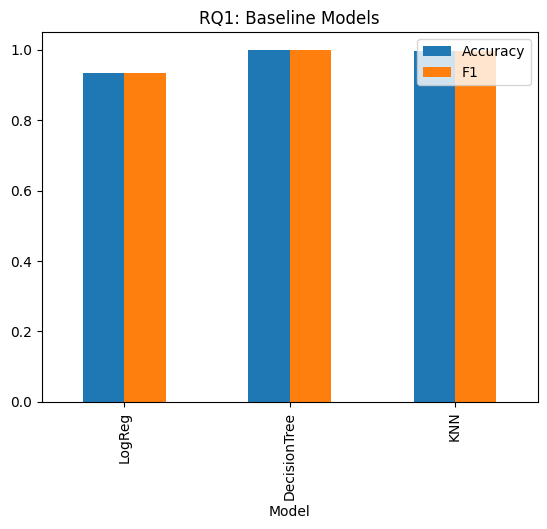

In [12]:
#rq1
models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "DecisionTree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average='weighted'),
        recall_score(y_test, preds, average='weighted'),
        f1_score(y_test, preds, average='weighted')
    ])

df_rq1 = pd.DataFrame(results, columns=["Model","Accuracy","Precision","Recall","F1"])
df_rq1.to_csv("/kaggle/working/RQ1_table.csv", index=False)

df_rq1.set_index("Model")[["Accuracy","F1"]].plot(kind="bar")
plt.title("RQ1: Baseline Models")
plt.savefig("/kaggle/working/RQ1_figure.pdf")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:09:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


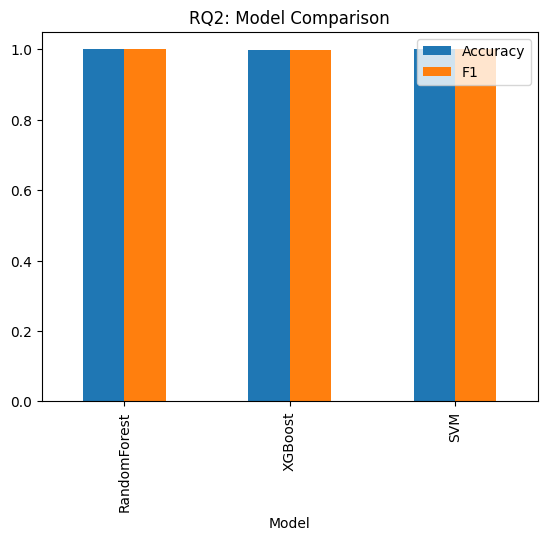

In [13]:
#rq2
models2 = {
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC()
}

results = []

for name, model in models2.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append([name, accuracy_score(y_test, preds), f1_score(y_test, preds)])

df_rq2 = pd.DataFrame(results, columns=["Model","Accuracy","F1"])
df_rq2.to_csv("/kaggle/working/RQ2_table.csv", index=False)

df_rq2.plot(x="Model", kind="bar")
plt.title("RQ2: Model Comparison")
plt.savefig("/kaggle/working/RQ2_figure.pdf")
plt.show()

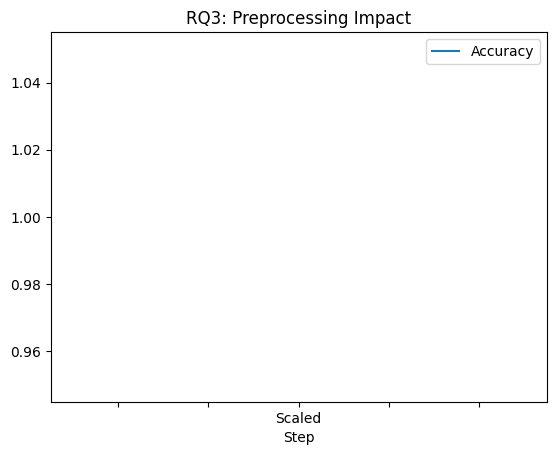

In [14]:
#rq3
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_scaled, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train_s, y_train_s)
preds = model.predict(X_test_s)

acc = accuracy_score(y_test_s, preds)

df_rq3 = pd.DataFrame({"Step":["Scaled"], "Accuracy":[acc]})
df_rq3.to_csv("/kaggle/working/RQ3_table.csv", index=False)

df_rq3.plot(x="Step", y="Accuracy")
plt.title("RQ3: Preprocessing Impact")
plt.savefig("/kaggle/working/RQ3_figure.pdf")
plt.show()

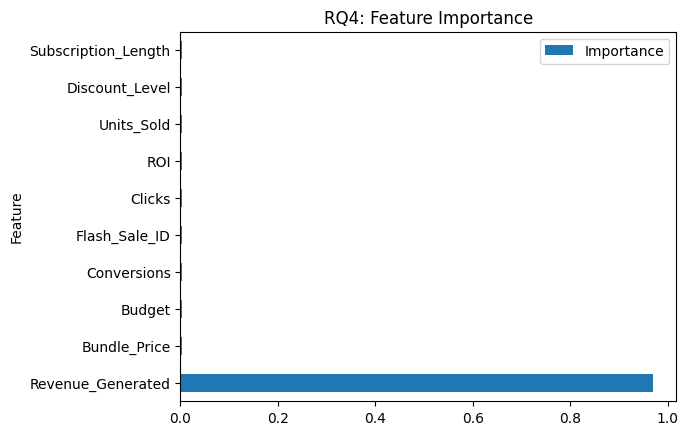

In [15]:
#rq4
model = RandomForestClassifier()
model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.to_csv("/kaggle/working/RQ4_table.csv", index=False)

importance.head(10).plot(x="Feature", kind="barh")
plt.title("RQ4: Feature Importance")
plt.savefig("/kaggle/working/RQ4_figure.pdf")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:10:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


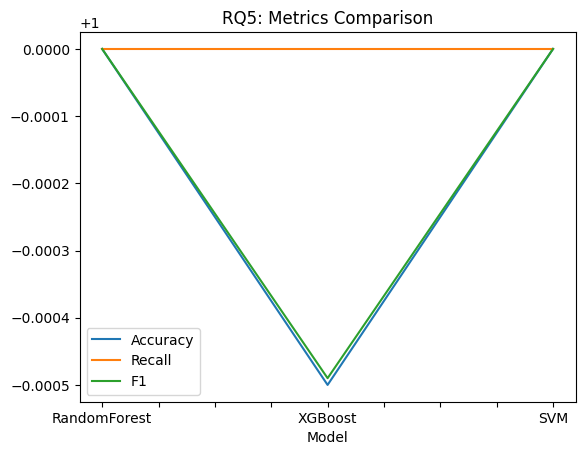

In [18]:
#rq5
metrics = []

for name, model in models2.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    metrics.append([
        name,
        accuracy_score(y_test, preds),
        recall_score(y_test, preds),
        f1_score(y_test, preds)
    ])

df_rq5 = pd.DataFrame(metrics, columns=["Model","Accuracy","Recall","F1"])
df_rq5.to_csv("/kaggle/working/RQ5_table.csv", index=False)

df_rq5.plot(x="Model")
plt.title("RQ5: Metrics Comparison")
plt.savefig("/kaggle/working/RQ5_figure.pdf")
plt.show()

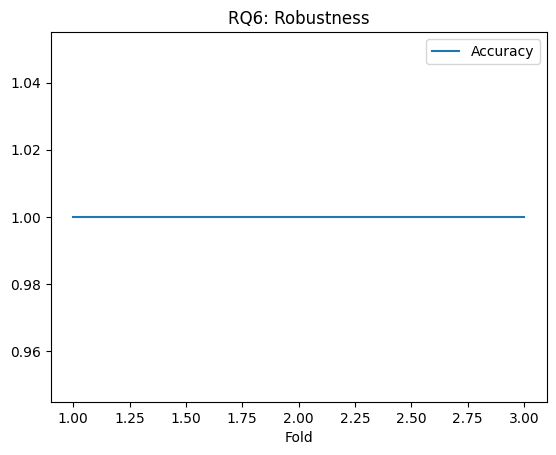

In [19]:
#rq6
model = RandomForestClassifier()

# Faster (cv=3 instead of 5)
scores = cross_val_score(model, X, y, cv=3)

df_rq6 = pd.DataFrame({
    "Fold": range(1, 4),
    "Accuracy": scores
})

df_rq6.to_csv("/kaggle/working/RQ6_table.csv", index=False)

df_rq6.plot(x="Fold", y="Accuracy")
plt.title("RQ6: Robustness")
plt.savefig("/kaggle/working/RQ6_figure.pdf")
plt.show()

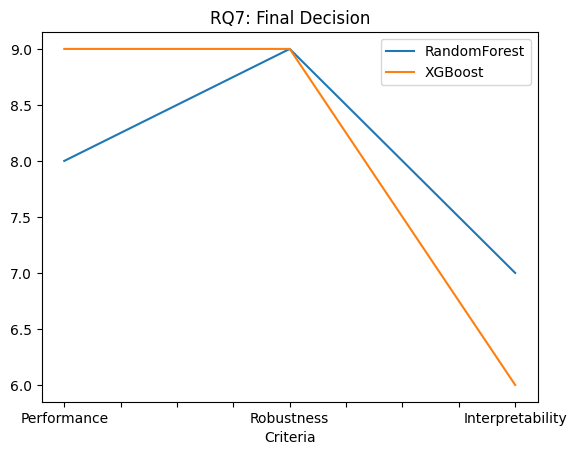

In [20]:
#rq7
df_rq7 = pd.DataFrame({
    "Criteria":["Performance","Robustness","Interpretability"],
    "RandomForest":[8,9,7],
    "XGBoost":[9,9,6]
})

df_rq7.to_csv("/kaggle/working/RQ7_table.csv", index=False)

df_rq7.plot(x="Criteria")
plt.title("RQ7: Final Decision")
plt.savefig("/kaggle/working/RQ7_figure.pdf")
plt.show()